In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os

In [11]:
# Dataset paths
TRAIN_DIR = "Jute_Pest_Dataset_Split/train"
VALID_DIR = "Jute_Pest_Dataset_Split/val"
TEST_DIR = "Jute_Pest_Dataset_Split/test"

# Dataset parameters
IMG_HEIGHT = 224  # Standard size for most pre-trained models
IMG_WIDTH = 224
BATCH_SIZE = 16
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)

In [12]:
def create_data_generators():
    """
    Create data generators for train, validation, and test sets.
    Uses ImageDataGenerator for data augmentation and preprocessing.
    """
    # Training data augmentation
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    
    # Validation and test data (only rescaling, no augmentation)
    val_test_datagen = ImageDataGenerator(rescale=1./255)
    
    # Create generators
    train_generator = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True
    )
    
    valid_generator = val_test_datagen.flow_from_directory(
        VALID_DIR,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    
    test_generator = val_test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    
    # Get number of classes
    num_classes = len(train_generator.class_indices)
    class_names = list(train_generator.class_indices.keys())
    
    print(f"\nDataset Information:")
    print(f"Number of classes: {num_classes}")
    print(f"Class names: {class_names}")
    print(f"Training samples: {train_generator.samples}")
    print(f"Validation samples: {valid_generator.samples}")
    print(f"Test samples: {test_generator.samples}")
    
    return train_generator, valid_generator, test_generator, num_classes, class_names

train_gen, valid_gen, test_gen, num_classes, class_names = create_data_generators()

Found 5005 images belonging to 17 classes.
Found 1073 images belonging to 17 classes.
Found 1102 images belonging to 17 classes.

Dataset Information:
Number of classes: 17
Class names: ['Beet Armyworm', 'Black Hairy', 'Cutworm', 'Field Cricket', 'Jute Aphid', 'Jute Hairy', 'Jute Red Mite', 'Jute Semilooper', 'Jute Stem Girdler', 'Jute Stem Weevil', 'Leaf Beetle', 'Mealybug', 'Pod Borer', 'Scopula Emissaria', 'Termite', 'Termite odontotermes (Rambur)', 'Yellow Mite']
Training samples: 5005
Validation samples: 1073
Test samples: 1102


In [13]:

def create_resnet_transfer_model(input_shape, num_classes, trainable_layers=0):
    """
    Create a transfer learning model using pre-trained ResNet50.
    """
    # Load pre-trained ResNet50 (without top classification layer)
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    # Freeze the base model initially
    base_model.trainable = False
    
    # Optionally unfreeze some layers for fine-tuning
    if trainable_layers > 0:
        base_model.trainable = True
        # Freeze all layers except the last trainable_layers
        for layer in base_model.layers[:-trainable_layers]:
            layer.trainable = False
    
    # Create new model with custom classification head
    inputs = keras.Input(shape=input_shape)
    
    # Pre-process inputs for ResNet50
    x = keras.applications.resnet50.preprocess_input(inputs)
    
    # Pass through base model
    x = base_model(x, training=False)
    
    # Add custom classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs)
    
    return model

# 1. ResNet50 Transfer Learning
print("\nCreating ResNet50 model...")
resnet_model = create_resnet_transfer_model(INPUT_SHAPE, num_classes, 
                                            trainable_layers=2)
print(f"\nResNet50 Total Parameters: {resnet_model.count_params():,}")
trainable_params = sum([tf.keras.backend.count_params(w) 
                        for w in resnet_model.trainable_weights])
print(f"ResNet50 Trainable Parameters: {trainable_params:,}")


Creating ResNet50 model...

ResNet50 Total Parameters: 24,116,625
ResNet50 Trainable Parameters: 528,913


In [14]:
def create_inception_transfer_model(input_shape, num_classes, trainable_layers=0):
    """
    Create a transfer learning model using pre-trained InceptionV3 (ImageNet).

    """
    # Load pre-trained InceptionV3 (without top classification layer)
    base_model = InceptionV3(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    # Freeze the base model initially
    base_model.trainable = False
    
    # Optionally unfreeze some layers for fine-tuning
    if trainable_layers > 0:
        base_model.trainable = True
        # Freeze all layers except the last trainable_layers
        for layer in base_model.layers[:-trainable_layers]:
            layer.trainable = False
    
    # Create new model with custom classification head
    inputs = keras.Input(shape=input_shape)
    
    # Pre-process inputs for InceptionV3
    x = keras.applications.inception_v3.preprocess_input(inputs)
    
    # Pass through base model
    x = base_model(x, training=False)
    
    # Add custom classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs)
    
    return model

# 2. InceptionV3 (ImageNet) Transfer Learning
print("\nCreating InceptionV3 (ImageNet) model...")
inception_model = create_inception_transfer_model(INPUT_SHAPE, num_classes, 
                                                    trainable_layers=15)
print(f"\nInceptionV3 Total Parameters: {inception_model.count_params():,}")
trainable_params = sum([tf.keras.backend.count_params(w) 
                        for w in inception_model.trainable_weights])
print(f"InceptionV3 Trainable Parameters: {trainable_params:,}")


Creating InceptionV3 (ImageNet) model...

InceptionV3 Total Parameters: 22,989,617
InceptionV3 Trainable Parameters: 1,580,689


In [15]:
# Train all models

def train_model(model, train_gen, val_gen, model_name, epochs=5, learning_rate=0.001):

    # Compile model with lower initial learning rate for better convergence
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy', 'top_k_categorical_accuracy']  # Added top-k for monitoring
    )
    
    # Callbacks - optimized for accuracy improvement
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_accuracy',  # Monitor validation accuracy instead of loss
        patience=15,  # Increased patience to allow more time for improvement
        mode='max',  # Maximize accuracy
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',  # Monitor accuracy for learning rate reduction
        factor=0.5,  # Reduce LR by half
        patience=10,  # Wait 5 epochs before reducing
        mode='max',  # Maximize accuracy
        min_lr=1e-7,
        verbose=1
    )
    
    model_checkpoint = keras.callbacks.ModelCheckpoint(
        f'{model_name.replace(" ", "_").lower()}_best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    
    # Additional callback to stop if validation accuracy plateaus
    plateau_callback = keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        mode='max',
        min_delta=0.001,  # Minimum change to qualify as improvement
        restore_best_weights=True,
        verbose=1
    )
    
    # Train model
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"Model will train for up to {epochs} epochs")
    print(f"Initial learning rate: {learning_rate}")
    print(f"Early stopping on val_accuracy with patience=25")
    print(f"{'='*60}\n")
    
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=[early_stopping, reduce_lr, model_checkpoint, plateau_callback],
        verbose=1
    )
    
    return history





In [16]:
histories = []

In [17]:
models = [inception_model]
model_names = ['InceptionV3']

for model, name in zip(models, model_names):
    history = train_model(
        model, train_gen, valid_gen,
        model_name=name,
        epochs=20,
        learning_rate=0.001
    )
    histories.append(history)


Training InceptionV3
Model will train for up to 20 epochs
Initial learning rate: 0.001
Early stopping on val_accuracy with patience=25

Epoch 1/20


313/313 [==============================] - ETA: 0s - loss: 2.8643 - accuracy: 0.1485 - top_k_categorical_accuracy: 0.4985
Epoch 1: val_accuracy improved from -inf to 0.16309, saving model to inceptionv3_best_model.h5


c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


313/313 [==============================] - 245s 768ms/step - loss: 2.8643 - accuracy: 0.1485 - top_k_categorical_accuracy: 0.4985 - val_loss: 2.7746 - val_accuracy: 0.1631 - val_top_k_categorical_accuracy: 0.5210 - lr: 0.0010
Epoch 2/20
313/313 [==============================] - ETA: 0s - loss: 2.5668 - accuracy: 0.2020 - top_k_categorical_accuracy: 0.5902
Epoch 2: val_accuracy improved from 0.16309 to 0.23486, saving model to inceptionv3_best_model.h5
313/313 [==============================] - 202s 647ms/step - loss: 2.5668 - accuracy: 0.2020 - top_k_categorical_accuracy: 0.5902 - val_loss: 2.3656 - val_accuracy: 0.2349 - val_top_k_categorical_accuracy: 0.6589 - lr: 0.0010
Epoch 3/20
313/313 [==============================] - ETA: 0s - loss: 2.4223 - accuracy: 0.2246 - top_k_categorical_accuracy: 0.6402
Epoch 3: val_accuracy did not improve from 0.23486
313/313 [==============================] - 195s 624ms/step - loss: 2.4223 - accuracy: 0.2246 - top_k_categorical_accuracy: 0.6402 - v

In [19]:
# Evaluate all models

def evaluate_model(model, test_gen, model_name, class_names):
    
    print(f"Evaluating {model_name}")
    
    # Reset test generator
    test_gen.reset()
    
    # Predictions
    y_pred_probs = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # True labels
    y_true = test_gen.classes
    
    # Test accuracy
    test_loss, test_acc = model.evaluate(test_gen, verbose=0)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    
    # Classification report
    print("\nClassification Report:")
    report = classification_report(y_true, y_pred, target_names=class_names)
    print(report)
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    return {
        'test_loss': test_loss,
        'test_accuracy': test_acc,
        'predictions': y_pred,
        'true_labels': y_true,
        'confusion_matrix': cm,
        'classification_report': classification_report(y_true, y_pred, 
                                                      target_names=class_names,
                                                      output_dict=True)
    }

results = []
for model, name in zip(models, model_names):
    result = evaluate_model(model, test_gen, name, class_names)
    results.append(result)

Evaluating InceptionV3
69/69 [==============================] - 27s 396ms/step


ValueError: too many values to unpack (expected 2)

GENERATING COMPARISON PLOTS


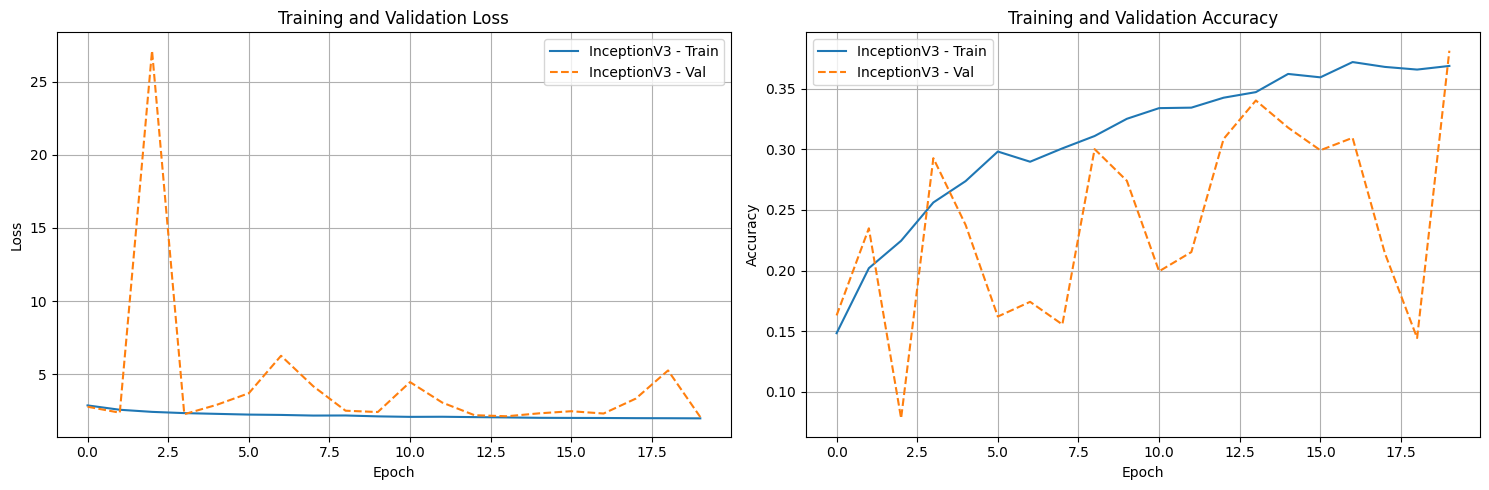

ValueError: Number of columns must be a positive integer, not 0

<Figure size 0x500 with 0 Axes>

In [20]:
def plot_training_history(histories, model_names):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot loss
    for history, name in zip(histories, model_names):
        axes[0].plot(history.history['loss'], label=f'{name} - Train')
        axes[0].plot(history.history['val_loss'], label=f'{name} - Val', linestyle='--')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Plot accuracy
    for history, name in zip(histories, model_names):
        axes[1].plot(history.history['accuracy'], label=f'{name} - Train')
        axes[1].plot(history.history['val_accuracy'], label=f'{name} - Val', linestyle='--')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.savefig('model_comparison_training.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_confusion_matrices(results, model_names, class_names=None):
    n_models = len(results)
    fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))
    
    if n_models == 1:
        axes = [axes]
    
    for idx, (result, name) in enumerate(zip(results, model_names)):
        sns.heatmap(result['confusion_matrix'], annot=True, fmt='d', 
                   cmap='Blues', ax=axes[idx],
                   xticklabels=class_names if class_names else 'auto',
                   yticklabels=class_names if class_names else 'auto')
        axes[idx].set_title(f'Confusion Matrix - {name}')
        axes[idx].set_ylabel('True Label')
        axes[idx].set_xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.savefig('confusion_matrices_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_performance_comparison(results, model_names):
    """
    Create bar plots comparing model performance metrics.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Extract metrics
    accuracies = [r['test_accuracy'] for r in results]
    losses = [r['test_loss'] for r in results]
    
    # Plot accuracy comparison
    axes[0].bar(model_names, accuracies, color=['blue', 'green', 'orange'])
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Test Accuracy Comparison')
    axes[0].set_ylim([0, 1])
    for i, v in enumerate(accuracies):
        axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom')
    
    # Plot loss comparison
    axes[1].bar(model_names, losses, color=['blue', 'green', 'orange'])
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Test Loss Comparison')
    for i, v in enumerate(losses):
        axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

  
    
# Visualize comparisons
print("GENERATING COMPARISON PLOTS")
print("="*60)

plot_training_history(histories, model_names)
plot_confusion_matrices(results, model_names, class_names)
plot_performance_comparison(results, model_names)

# Print summary comparison
print("FINAL PERFORMANCE SUMMARY")
print("="*60)

for name, result in zip(model_names, results):
    print(f"\n{name}:")
    print(f"  Test Accuracy: {result['test_accuracy']:.4f}")
    print(f"  Test Loss: {result['test_loss']:.4f}")
    
    # Get per-class metrics
    report = result['classification_report']
    print(f"\n  Per-Class Metrics:")
    for class_name in class_names:
        if class_name in report:
            print(f"    {class_name}:")
            print(f"      Precision: {report[class_name]['precision']:.4f}")
            print(f"      Recall: {report[class_name]['recall']:.4f}")
            print(f"      F1-Score: {report[class_name]['f1-score']:.4f}")

# Save final models
print("SAVING MODELS")
print("="*60)

for model, name in zip(models, model_names):
    filename = f'{name.replace(" ", "_").lower()}_final_model.h5'
    model.save(filename)
    print(f"Saved: {filename}")

print("\n" + "="*60)
print("COMPARISON COMPLETE!")
print("="*60)
print("\nGenerated files:")
print("  - model_comparison_training.png")
print("  - confusion_matrices_comparison.png")
print("  - performance_comparison.png")
print("  - resnet50_best_model.h5")



